# Multi-modal RAG with LangChain

## SetUp

Install the dependencies you need to run the notebook.

In [1]:
# unstructured[all-docs] often fails on macOS ARM (pi-heif build). Use wheels + inference stack:
%pip install --upgrade pip
%pip install --no-compile -Uq unstructured unstructured-pytesseract pypdf pdfminer.six pi-heif unstructured-inference pdf2image pillow lxml --only-binary pi-heif
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq langsmith
%pip install -Uq python-dotenv


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:

# keys for the services we will use are OPENAI_API_KEY, GROQ_API_KEY, LANGCHAIN_API_KEY, LANGCHAIN_TRACING_V2

import os
from dotenv import load_dotenv

load_dotenv("/Users/priya/Documents/Adanced RAG/.env")

# Hugging Face clients expect HF_TOKEN. Keep supporting the older HF_API_KEY name in .env.
if not os.getenv("HF_TOKEN") and os.getenv("HF_API_KEY"):
    os.environ["HF_TOKEN"] = os.getenv("HF_API_KEY")

# LangSmith observability for LangChain runs. Newer LangSmith env vars are LANGSMITH_*;
# older notebooks often use LANGCHAIN_* names, so support both.
if not os.getenv("LANGSMITH_API_KEY") and os.getenv("LANGCHAIN_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

os.environ["LANGSMITH_TRACING"] = os.getenv(
    "LANGSMITH_TRACING",
    os.getenv("LANGCHAIN_TRACING_V2", "true"),
).lower()
os.environ["LANGSMITH_ENDPOINT"] = os.getenv(
    "LANGSMITH_ENDPOINT",
    "https://api.smith.langchain.com",
)
os.environ["LANGSMITH_PROJECT"] = os.getenv(
    "LANGSMITH_PROJECT",
    os.getenv("LANGCHAIN_PROJECT", "advanced-rag-notebook"),
)

print("LangSmith tracing:", os.environ["LANGSMITH_TRACING"])
print("LangSmith project:", os.environ["LANGSMITH_PROJECT"])
print("LangSmith API key loaded:", bool(os.getenv("LANGSMITH_API_KEY")))


True

## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [3]:
import os, shutil
os.environ["PATH"] = "/opt/homebrew/bin:/usr/local/bin:" + os.environ.get("PATH", "")
print(shutil.which("pdfinfo"))

/opt/homebrew/bin/pdfinfo


In [4]:

from unstructured.partition.pdf import partition_pdf

#output_path = "./Adanced RAG/"
file_path = "/Users/priya/Documents/Adanced RAG/attention.pdf"

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

No languages specified, defaulting to English.


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [5]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [6]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements

In [7]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'a3de4b8d-23e9-40a1-b13e-220fcc304a00',
 'text': 'Scaled Dot-Product Attention Multi-Head Attention EE Scaled Dot-Product Attention 4',
 'metadata': {'detection_class_prob': 0.8531951308250427,
  'coordinates': {'points': ((np.float64(760.9631958007812),
     np.float64(348.6939392089844)),
    (np.float64(760.9631958007812), np.float64(1171.763671875)),
    (np.float64(2296.71044921875), np.float64(1171.763671875)),
    (np.float64(2296.71044921875), np.float64(348.6939392089844))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-05-07T12:52:03',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [8]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [9]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

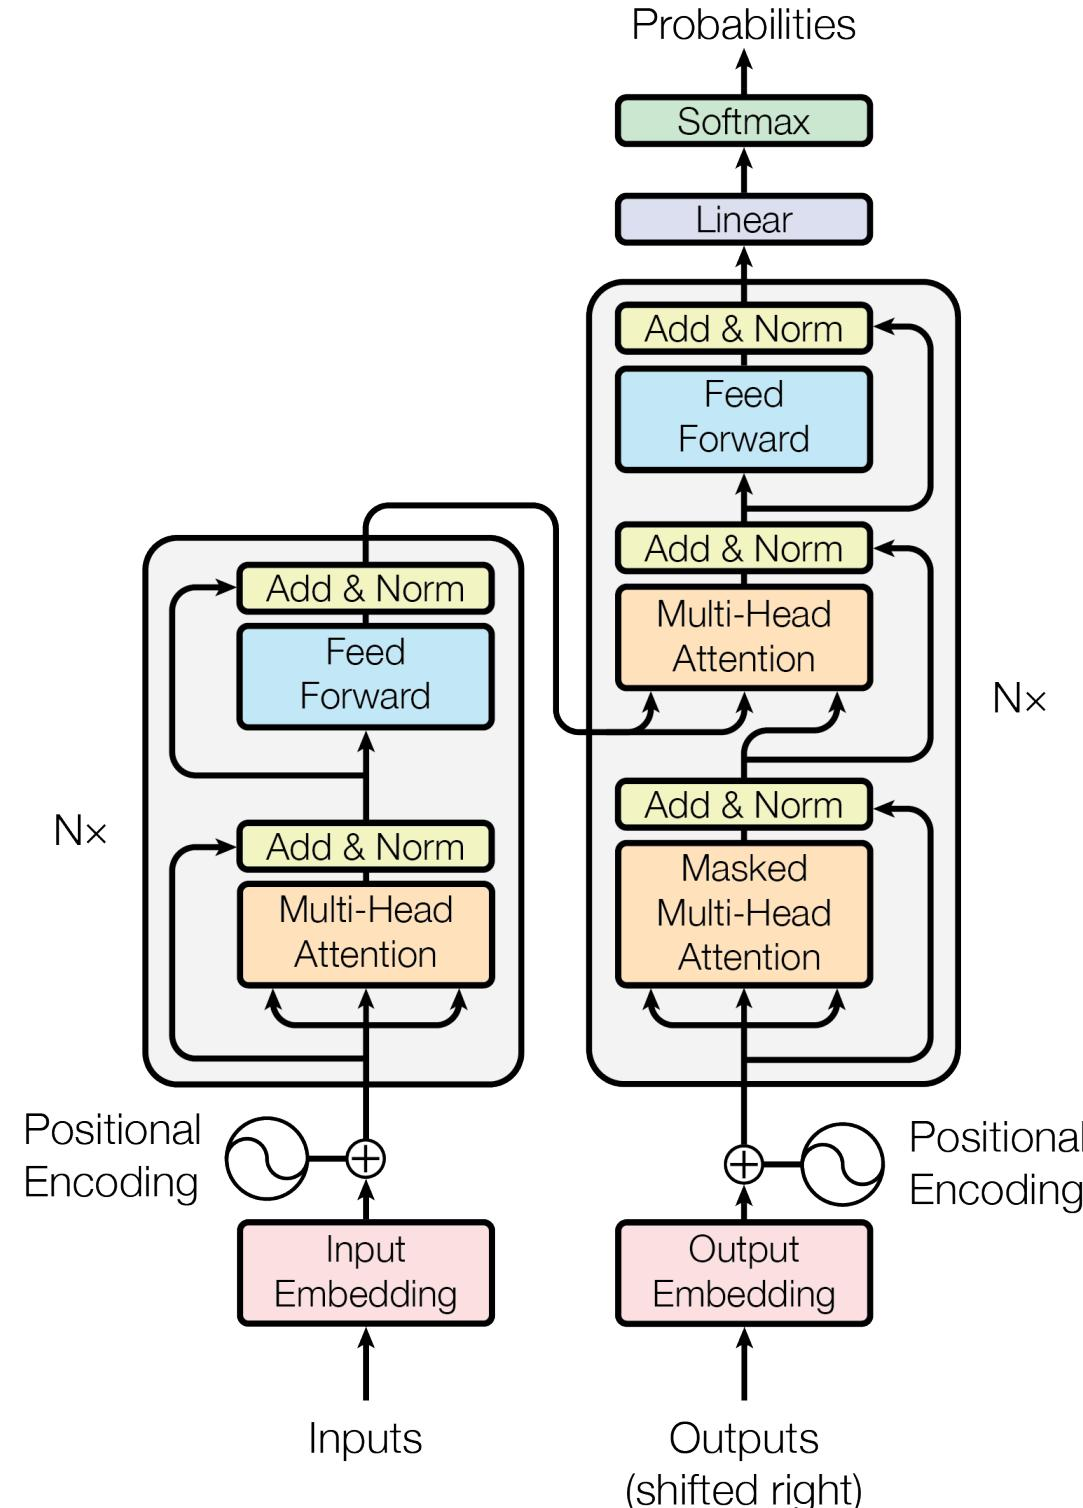

In [10]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [11]:
%pip install -Uq langchain-groq

Note: you may need to restart the kernel to use updated packages.


In [12]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [13]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additional comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain. Keep responses short to stay under Groq's free/on-demand TPM limit.
model = ChatGroq(
    temperature=0.5,
    model="llama-3.1-8b-instant",
    max_tokens=256,
    max_retries=6,
)
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [ ]:
import re
import time


def _wait_seconds_from_error(error, default=10):
    match = re.search(r"try again in ([0-9.]+)s", str(error), flags=re.IGNORECASE)
    return float(match.group(1)) + 1 if match else default


def summarize_safely(items, pause_seconds=8, max_attempts=6):
    """Run Groq requests sequentially so we do not exceed the 6000 TPM on-demand limit."""
    summaries = []
    for i, item in enumerate(items, start=1):
        for attempt in range(1, max_attempts + 1):
            try:
                summaries.append(summarize_chain.invoke(item))
                print(f"Summarized {i}/{len(items)}")
                time.sleep(pause_seconds)
                break
            except Exception as e:
                if "rate_limit" not in str(e).lower() and "429" not in str(e):
                    raise
                wait_seconds = _wait_seconds_from_error(e, default=pause_seconds * attempt)
                print(f"Rate limit hit. Waiting {wait_seconds:.1f}s before retry {attempt}/{max_attempts}...")
                time.sleep(wait_seconds)
        else:
            raise RuntimeError(f"Failed to summarize item {i} after {max_attempts} attempts")
    return summaries


# Summarize text and tables sequentially to avoid Groq rate limits.
text_summaries = summarize_safely(texts)

tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_safely(tables_html)

Summarized 1/13
Summarized 2/13
Summarized 3/13
Summarized 4/13
Summarized 5/13
Summarized 6/13
Summarized 7/13
Summarized 8/13
Summarized 9/13
Summarized 10/13
Summarized 11/13
Summarized 12/13
Summarized 13/13
Summarized 1/4
Summarized 2/4
Summarized 3/4
Summarized 4/4


In [18]:
text_summaries

['The Transformer model, a neural network architecture, replaces traditional recurrent and convolutional networks with attention mechanisms, achieving superior results in machine translation tasks and requiring less training time.',
 'Recurrent neural networks have been widely used in sequence modeling and transduction problems, but their sequential nature limits parallelization and efficiency. Attention mechanisms have improved sequence modeling, but often rely on recurrent networks. This work proposes the Transformer, a model that uses self-attention to draw global dependencies between input and output, allowing for more parallelization and achieving state-of-the-art translation quality in a short training time.',
 'The Transformer model architecture consists of an encoder and decoder with stacked self-attention and fully connected layers. The encoder has 6 identical layers with two sub-layers: multi-head self-attention and position-wise feed-forward networks. The decoder has 6 ident

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [19]:
%pip install -Uq langchain_openai

Note: you may need to restart the kernel to use updated packages.


In [20]:
from langchain_openai import ChatOpenAI

prompt_template = """Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOpenAI(model="gpt-4o-mini") | StrOutputParser()


image_summaries = chain.batch(images)

In [21]:
image_summaries

['The diagram illustrates the architecture of the Transformer model used in natural language processing and machine learning tasks. Here’s a detailed description of its components:\n\n1. **Overall Structure**: The Transformer architecture is presented in a flowchart style, showcasing both the encoder and decoder parts. The design uses various colors to differentiate between different modules.\n\n2. **Input Section**:\n   - At the bottom, there is a label **"Inputs"** that leads to an **"Input Embedding"** box, which represents how input data is transformed into a vector space. This is accompanied by **"Positional Encoding"**, indicating the importance of the position of words within the sentence.\n   - A circle and plus sign signifies that positional encoding is added to the input embedding.\n\n3. **Encoder Block**:\n   - The left section includes an **"Add & Norm"** component, which implies adding and normalizing inputs.\n   - This is followed by a **"Feed Forward"** layer, which proc

In [22]:
print(image_summaries[1])

The image depicts two components of the transformer architecture: "Scaled Dot-Product Attention" on the left and "Multi-Head Attention" on the right.

### Scaled Dot-Product Attention (Left Side)
- **Overall Structure**: A vertical stack with labeled boxes indicating various steps in the attention mechanism.
- **Components**:
  - **MatMul** (Mathematical Multiplication): Located at the bottom of the stack and depicts the initial matrix multiplication step. It takes inputs Q (Query), K (Key), and V (Value).
  - **Scale**: Above MatMul, a box for scaling is noted, which adjusts the product's magnitude to stabilize gradient updates.
  - **Mask (opt.)**: An optional masking step to prevent attention to certain positions, shown in a pink box above Scale.
  - **SoftMax**: Positioned above the Mask, it computes the softmax of the scaled values to create attention weights.
  - **Final MatMul**: The last step performs another matrix multiplication to combine the attention weights with V.

### M

## Load data and summaries to vectorstore

### Create the vectorstore

In [24]:
import uuid

from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_core.stores import InMemoryStore
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

/var/folders/v1/jx7kn_7j2955pbwbntctrjvm0000gn/T/ipykernel_35677/136585587.py:10: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())


### Load the summaries and link the to the original data

In [25]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

### Check retrieval

In [26]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)

In [27]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

[36] Christian Szegedy, Vincent Vanhoucke, Sergey Ioffe, Jonathon Shlens, and Zbigniew Wojna. Rethinking the inception architecture for computer vision. CoRR, abs/1512.00567, 2015.

[37] Vinyals & Kaiser, Koo, Petrov, Sutskever, and Hinton. Grammar as a foreign language. In Advances in Neural Information Processing Systems, 2015.

[38] Yonghui Wu, Mike Schuster, Zhifeng Chen, Quoc V Le, Mohammad Norouzi, Wolfgang Macherey, Maxim Krikun, Yuan Cao, Qin Gao, Klaus Macherey, et al. Google’s neural machine translation system: Bridging the gap between human and machine translation. arXiv preprint arXiv: 1609.08144, 2016.

[39] Jie Zhou, Ying Cao, Xuguang Wang, Peng Li, and Wei Xu. Deep recurrent models with fast-forward connections for neural machine translation. CoRR, abs/1606.04199, 2016.

[40] Muhua Zhu, Yue Zhang, Wenliang Chen, Min Zhang, and Jingbo Zhu. Fast and accurate shift-reduce constituent parsing. In Proceedings of the 51st Annual Meeting of the ACL (Volume 1; Long Papers), page

## RAG pipeline

In [28]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

In [29]:
response = chain.invoke(
    "What is the attention mechanism?"
)

print(response)

The attention mechanism is a method used in machine learning to dynamically focus on different parts of an input sequence when producing an output. It employs a mapping of queries to a set of key-value pairs, where the query generates weights for the values based on their compatibility with the keys. 

In the case of Scaled Dot-Product Attention, the mechanism calculates the dot product of queries and keys, scales the result, and applies a softmax function to derive the weights. These weights are then used to compute a weighted sum of the values, yielding the output. This allows the model to capture long-distance dependencies and relationships in the data effectively. 

In visual terms, the attention mechanism can be depicted through connections between words, as seen in the provided images, illustrating how different parts of the sequence influence each other.


In [30]:
response = chain_with_sources.invoke(
    "What is multihead?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

Response: Multi-head attention is a mechanism in the Transformer model that allows it to jointly attend to information from different representation subspaces at various positions. Instead of using a single attention function, multi-head attention linearly projects the queries, keys, and values multiple times (h times), creating different learned linear projections. Each of these projections performs the attention function in parallel, resulting in d-dimensional output values that are concatenated and then projected again to produce the final output.

This approach helps overcome the limitations of a single attention head, such as overly averaging the information, and allows for more complex representation learning from the input data. The Transformer typically employs multiple parallel attention heads, with 8 heads being used in the context described. Each head focuses on different parts of the input, enhancing the model's ability to capture a richer set of relationships within the da